# Affine dataset - two jobs
- first try direct optimization of the OneSidedSDFLoss if rot and shift params can be directly optimized by grad descent (one example in single batch)
- then create pipeline that consumes the image and directly predicts the params

## View dataset images and loading

In [34]:
from constraints import get_experiment_folder,get_data_folder,show_torch_image
from pathlib import Path
from matplotlib import pyplot as plt 
import numpy as np
import torch

from constraints.datatools import CachedArtificalDataset
FOLDER =get_experiment_folder(Path("ex3")/"affine")
DATA = get_data_folder() / "artificial"/"downloaded"/"trn"
# AFFINE =  get_data_folder() / "artificial" / "affine"/ "trn"
AFFINE =  DATA / "affine"
DEFORMED = DATA / "deformed"

In [35]:
dataset = CachedArtificalDataset(AFFINE,sdf_mode="kornia")

In [36]:
img = dataset[1]["image"]
template = dataset[1]["template"]

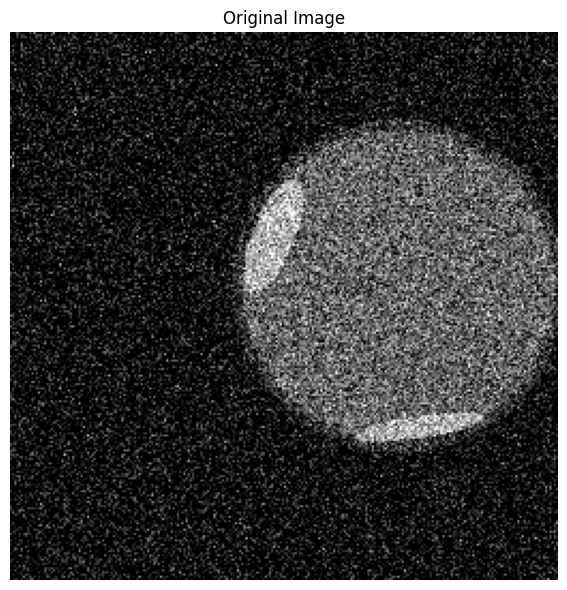

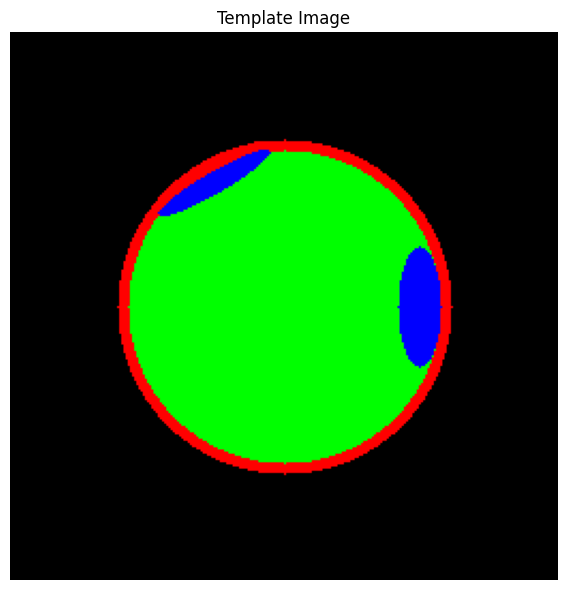

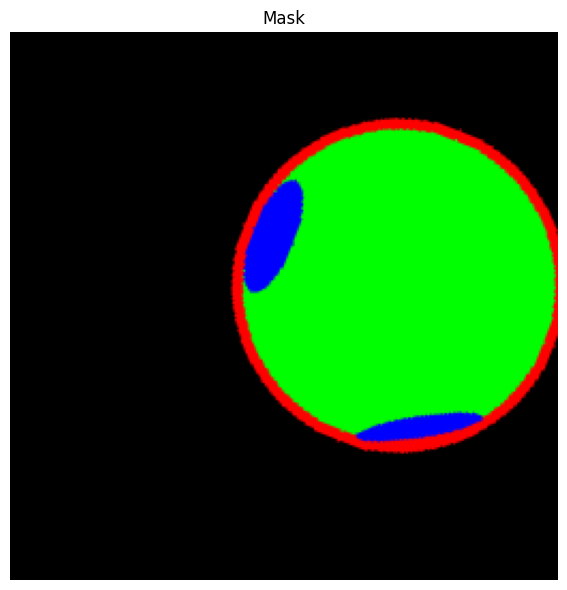

In [37]:
show_torch_image(img, title="Original Image",cmap="gray")
show_torch_image(template, title="Template Image")
show_torch_image(dataset[1]["mask"], title="Mask")

# Direct optimization of params

### Goal
- estimate meaningfullness of the signal

In [47]:
from constraints.losses import OneSideSDFSquare, CentroidLoss,OneSideSDF
from constraints.transforms import differentiable_rigid

In [39]:
class DirectOptimizer(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self._sigma = torch.nn.Parameter(torch.tensor(0.0)) # rotation
        self._tx = torch.nn.Parameter(torch.tensor(0.0)) # translation in x
        self._ty = torch.nn.Parameter(torch.tensor(0.0)) # translation in y
    def forward(self, template):
        return differentiable_rigid(template, self._sigma, self._tx, self._ty)


    

In [ ]:
def test_loss(loss_fn, dataset):
    violations =0
    NUM_RUNS = min(100, len(dataset))
    for k in range(NUM_RUNS):
        sample = dataset[k]
        # show_torch_image(sample["template"], title="Sample Template")
        # show_torch_image(sample["mask"], title="Sample Mask")
        net = DirectOptimizer()
        optimizer = torch.optim.Adam(net.parameters(), lr=0.05)
        mse_calc = torch.nn.MSELoss()
        NUM_ITERATIONS = 200
        for i in range(NUM_ITERATIONS):
            optimizer.zero_grad()
            transformed_template = net(sample["template"])
            loss = loss_fn(transformed_template, sample["sdf"])
            mse_err = mse_calc(transformed_template, sample["mask"])
            loss.backward()
            # mse_err.backward()
            optimizer.step()
            # if i % 10 == 0:
            if i == NUM_ITERATIONS - 1:
                print(f"Iteration {i}, Loss: {loss.item()}")
                if mse_err > 0.01:
                    violations += 1
                    # show_torch_image(sample["mask"], title=f"MASK")
                    # show_torch_image(transformed_template, title=f"Transformed Template at Iteration {i},loss={loss.item():.4f}, mse={mse_err:.4f}")
                print(f"MSE Error: {mse_err:.4f}, Loss: {loss.item():.4f}")

    violation_portion = violations / NUM_RUNS
    print(f"Portion of violations: {violation_portion:.2%} ({violations}/{NUM_RUNS})")

Iteration 199, Loss: 0.0008921052212826908
MSE Error: 0.0014, Loss: 0.0009
Iteration 199, Loss: 2.847972869873047
MSE Error: 0.0516, Loss: 2.8480
Iteration 199, Loss: 5.517849445343018
MSE Error: 0.0675, Loss: 5.5178
Iteration 199, Loss: 0.00015015107055660337
MSE Error: 0.0000, Loss: 0.0002
Iteration 199, Loss: 0.00015036144759505987
MSE Error: 0.0000, Loss: 0.0002
Iteration 199, Loss: 0.00017202511662617326
MSE Error: 0.0001, Loss: 0.0002
Iteration 199, Loss: 0.00014719080354552716
MSE Error: 0.0000, Loss: 0.0001
Iteration 199, Loss: 0.00026599480770528316
MSE Error: 0.0005, Loss: 0.0003
Iteration 199, Loss: 4.667860507965088
MSE Error: 0.0441, Loss: 4.6679
Iteration 199, Loss: 5.106994152069092
MSE Error: 0.0682, Loss: 5.1070
Iteration 199, Loss: 6.100624084472656
MSE Error: 0.0733, Loss: 6.1006
Iteration 199, Loss: 0.0
MSE Error: 0.0866, Loss: 0.0000
Iteration 199, Loss: 0.0059253075160086155
MSE Error: 0.0033, Loss: 0.0059
Iteration 199, Loss: 6.15579080581665
MSE Error: 0.0704, L